In [294]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist

In [295]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
import csv
from glob import glob
import pandas as po
import numpy as np
import PIL.Image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models, transforms
from torchvision.io import decode_image
from torchvision.utils import make_grid

%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [296]:
!7z x dataset.zip -o/content -Y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 705976966 bytes (674 MiB)

Extracting archive: dataset.zip
 52% 4096 Open              --
Path = dataset.zip
Type = zip
Physical Size = 705976966

  0%      0% 66         0% 87         0% 99         0% 108          0% 118          1% 132 - dataset/175807_futuro/245760_IMG_004.jpg                                                     1% 148          1% 172          1% 197          2% 228          2% 250          2% 265      

In [297]:
folder_path = '/content/dataset/*'

if os.path.exists('/content/dataset_label.csv'):
    os.remove('/content/dataset_label.csv')

with open('dataset_label.csv', 'w') as target:
  csv.writer(target).writerow(['Imagem', 'Label'])

label_n = 0
for folder_n in glob(folder_path):
  for img_n in glob(folder_n + '/*'):
    with open('dataset_label.csv', 'a') as target:
      csv.writer(target).writerow([img_n, label_n])
  label_n = label_n + 1

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = po.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [298]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
dataset = CustomImageDataset(
    annotations_file = '/content/dataset_label.csv',
    img_dir = '/content/dataset/*'
)

2
<class 'torch.Tensor'> <class 'numpy.int64'>
Shape da imagem: torch.Size([3, 500, 375])
Label: 14
Maior valor de intensidade da imagem: tensor(255, dtype=torch.uint8)
Menor valor de intensidade da imagem: tensor(0, dtype=torch.uint8)


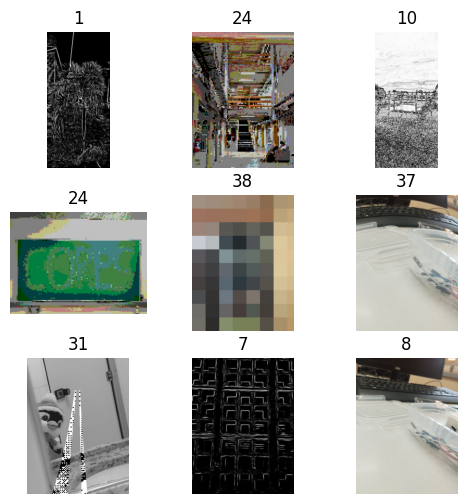

In [299]:
# Checando informações de dataset

dataset_example = random.choice(dataset)
print(len(dataset_example))
print(type(dataset_example[0]), type(dataset_example[1]))
print('Shape da imagem:', dataset_example[0].shape)
print('Label:', dataset_example[1])
print('Maior valor de intensidade da imagem:', torch.max(dataset_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(dataset_example[0]))

# Visualizando algumas imagens e labels do conjunto de dataset
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(dataset)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    if (img.shape[0] <= 3 and img.ndim == 3):
      img = img.permute(1, 2, 0)
    if (img.ndim == 3):
      plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    else:
      print("dimensões erradas")
plt.show()

In [300]:
# Separando os dados em dados de treinamento, validação e teste
dataset_randomize = po.read_csv('dataset_label.csv').sample(frac = 1)
dataset_randomize.to_csv('random.csv')

if os.path.exists('/content/training_dataset_label.csv'):
  os.remove('/content/training_dataset_label.csv')

if os.path.exists('/content/validation_dataset_label.csv'):
  os.remove('/content/validation_dataset_label.csv')

if os.path.exists('/content/test_dataset_label.csv'):
  os.remove('/content/test_dataset_label.csv')

with open('training_dataset_label.csv', 'w') as target:
  csv.writer(target).writerow(['Imagem', 'Label'])

with open('validation_dataset_label.csv', 'w') as target:
  csv.writer(target).writerow(['Imagem', 'Label'])

with open('test_dataset_label.csv', 'w') as target:
  csv.writer(target).writerow(['Imagem', 'Label'])

aux = 1
with open('/content/random.csv', 'r') as read_target:
  leitor = csv.reader(read_target)
  next(leitor)

  with open('/content/training_dataset_label.csv', 'a') as write_target:
    for linha in leitor:
      if (aux > 4000):
        break
      aux = aux + 1
      csv.writer(write_target).writerow(linha)

  with open('/content/validation_dataset_label.csv', 'a') as write_target:
    for linha in leitor:
      if (aux > 6000):
        break
      aux = aux + 1
      csv.writer(write_target).writerow(linha)

  with open('/content/test_dataset_label.csv', 'a') as write_target:
    for linha in leitor:
      csv.writer(write_target).writerow(linha)

In [301]:
# Criando os datasets de treinamento e validação
training_data = CustomImageDataset(
    annotations_file = '/content/training_dataset_label.csv',
    img_dir = '/content/dataset/*',
    transform = transforms.Resize((128, 128))
)

val_data = CustomImageDataset(
    annotations_file = '/content/validation_dataset_label.csv',
    img_dir = '/content/dataset/*',
    transform = transforms.Resize((128, 128))
)

test_data = CustomImageDataset(
    annotations_file = '/content/test_dataset_label.csv',
    img_dir = '/content/dataset/*',
    transform = transforms.Resize((128, 128))
)

2
<class 'torch.Tensor'> <class 'numpy.int64'>
Shape da imagem: torch.Size([3, 128, 128])
Label: 32
Maior valor de intensidade da imagem: tensor(254, dtype=torch.uint8)
Menor valor de intensidade da imagem: tensor(0, dtype=torch.uint8)


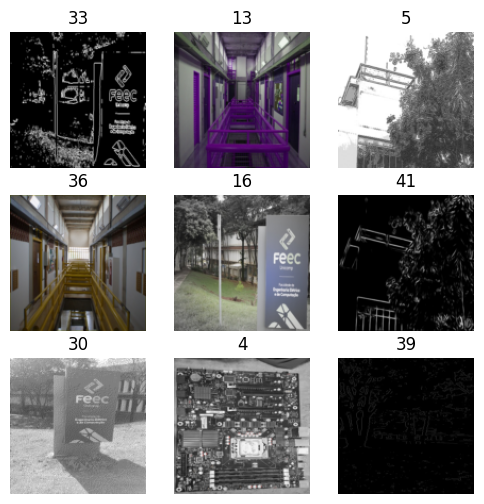

In [302]:
# Checando informações de uma amostra de treinamento

training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    if (img.shape[0] <= 3 and img.ndim == 3):
      img = img.permute(1, 2, 0)
    if (img.ndim == 3):
      plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    else:
      print("dimensões erradas")
plt.show()

2
<class 'torch.Tensor'> <class 'numpy.int64'>
Shape da imagem: torch.Size([3, 128, 128])
Label: 41
Maior valor de intensidade da imagem: tensor(187, dtype=torch.uint8)
Menor valor de intensidade da imagem: tensor(0, dtype=torch.uint8)


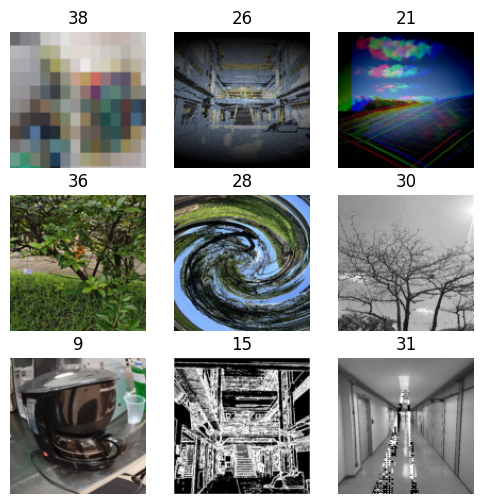

In [303]:
# Checando informações de uma amostra de validação

val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    if (img.shape[0] <= 3 and img.ndim == 3):
      img = img.permute(1, 2, 0)
    if (img.ndim == 3):
      plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    else:
      print("dimensões erradas")
plt.show()

2
<class 'torch.Tensor'> <class 'numpy.int64'>
Shape da imagem: torch.Size([3, 128, 128])
Label: 21
Maior valor de intensidade da imagem: tensor(224, dtype=torch.uint8)
Menor valor de intensidade da imagem: tensor(0, dtype=torch.uint8)


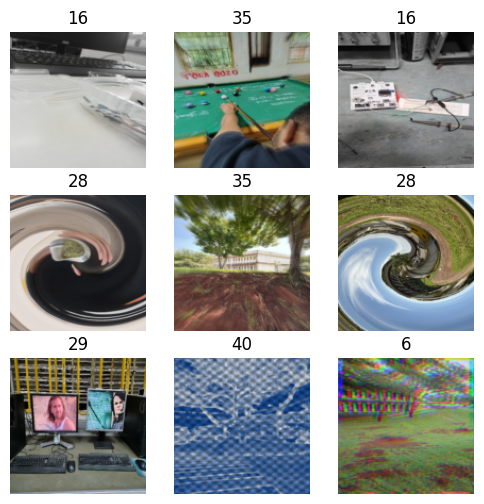

In [304]:
# Checando informações de uma amostra de teste

test_example = random.choice(test_data)
print(len(test_example))
print(type(test_example[0]), type(test_example[1]))
print('Shape da imagem:', test_example[0].shape)
print('Label:', test_example[1])
print('Maior valor de intensidade da imagem:', torch.max(test_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(test_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(test_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    if (img.shape[0] <= 3 and img.ndim == 3):
      img = img.permute(1, 2, 0)
    if (img.ndim == 3):
      plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    else:
      print("dimensões erradas")
plt.show()

In [305]:
# Hiperparâmetros
hparams = {"experiment_name": "Test_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 3,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_1
max_epochs: 10
batch_size: 100
nworkers: 2
nout: 10
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


In [306]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [307]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [308]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [309]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (3, 128, 128))

cpu
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 64, 64]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 64, 64]          128
├─ReLU: 1-3                              [-1, 64, 64, 64]          --
├─MaxPool2d: 1-4                         [-1, 64, 32, 32]          --
├─Sequential: 1-5                        [-1, 64, 32, 32]          --
|    └─BasicBlock: 2-1                   [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 32, 32]          128
|    |    └─ReLU: 3-3                    [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 32, 32]          128
|    |    └─ReLU: 3-6                    [-1, 64, 32, 32]          --
|    └─BasicBlock: 2-2                   [-1, 64, 32, 32]          

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 64, 64]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 64, 64]          128
├─ReLU: 1-3                              [-1, 64, 64, 64]          --
├─MaxPool2d: 1-4                         [-1, 64, 32, 32]          --
├─Sequential: 1-5                        [-1, 64, 32, 32]          --
|    └─BasicBlock: 2-1                   [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 32, 32]          128
|    |    └─ReLU: 3-3                    [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 32, 32]          128
|    |    └─ReLU: 3-6                    [-1, 64, 32, 32]          --
|    └─BasicBlock: 2-2                   [-1, 64, 32, 32]          --
|

In [310]:
class TrainNetwork(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

In [311]:
debug = True  # Turn this True to test the code with a quick run

# Initialization
model = TrainNetwork(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

# Todos datasets passam a ter tipo int

trainer.fit(model, train_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


Hyperparameters:

experiment_name: Test_1
max_epochs: 10
batch_size: 100
nworkers: 2
nout: 10
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


RuntimeError: expected scalar type Byte but found Float